### In this Notebook we try to figure out the spark features
- **Storage Formats**: We will compare row-based storage (CSV, JSON) with columnar storage (Parquet).

- **Data Compression**: We will see how formats like Parquet drastically reduce disk space without losing information.

- **Physical Partitioning**: We will learn how to organize data into folders based on a key column (e.g., date or city) so Spark only reads what it needs.

- **Predicate Pushdown**: A technical concept where Spark reads only the necessary columns and rows directly from storage.

In [15]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
from pyspark.sql import functions as F
import time
from pyspark.sql.functions import col, when, to_date, year, month, dayofmonth, trim, lower, round as spark_round,avg
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import time
import os
import shutil
from pyspark.sql import SparkSession

# ============================================
# SETUP
# ============================================
try:
    spark.stop()
except:
    pass

spark = SparkSession.builder \
    .appName("CSV vs Parquet") \
    .master("local[2]") \
    .config("spark.driver.memory", "1g") \
    .config("spark.sql.shuffle.partitions", "2") \
    .config("spark.default.parallelism", "2") \
    .getOrCreate()

# Verify configuration
print(f"Driver Memory: {spark.conf.get('spark.driver.memory')}")
print(f"Shuffle Partitions: {spark.conf.get('spark.sql.shuffle.partitions')}")
print(f"Master URL: {spark.conf.get('spark.master')}")


Driver Memory: 1g
Shuffle Partitions: 2
Master URL: local[2]


In [ ]:
csv_path = '/opt/spark/data/Network-Intrusion-SOS.csv' 
print("=" * 60) 
print("CSV vs PARQUET COMPARISON") 
print("=" * 60)

In [4]:
csv_path = '/opt/spark/data/'
df_csv = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv(csv_path)

CSV vs PARQUET COMPARISON


In [5]:
# ============================================
# STEP 1: READ CSV
# ============================================
print("\n📊 STEP 1: Reading CSV...")
start = time.time()
df_csv = spark.read.option('header', 'true').option('inferSchema', 'true').csv(csv_path)
csv_count = df_csv.count()
csv_time = time.time() - start
print(f"✅ CSV: {csv_time:.3f}s | {csv_count:,} rows")


📊 STEP 1: Reading CSV...
✅ CSV: 4.980s | 225,745 rows


In [6]:
print(f"\n💾 STEP 2: Writing Parquet...")

if os.path.exists(parquet_path):
    shutil.rmtree(parquet_path)
    print(f"   Cleaned old parquet")

df_csv.write.mode('overwrite').parquet(parquet_path)

if os.path.exists(parquet_path):
    files = [f for f in os.listdir(parquet_path) if f.endswith('.parquet')]
    print(f"✅ Created: {len(files)} parquet files")


💾 STEP 2: Writing Parquet...
✅ Created: 2 parquet files


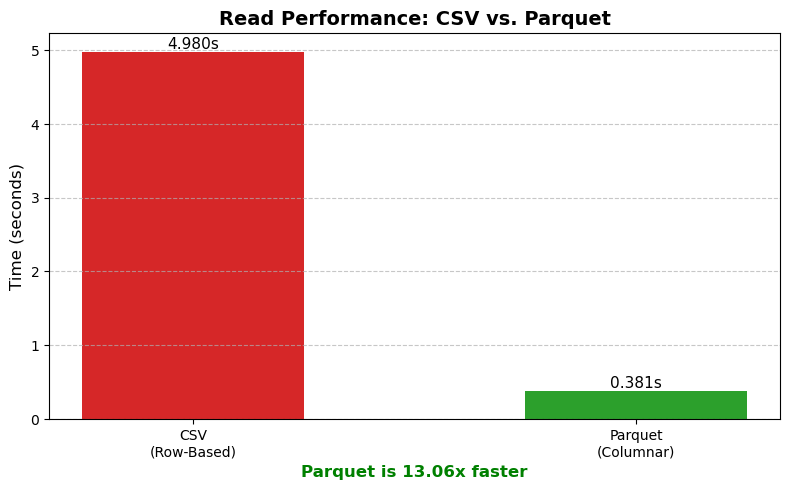

In [20]:
formats = ['CSV\n(Row-Based)', 'Parquet\n(Columnar)']
times = [csv_time, pq_time]
colors = ['#d62728', '#2ca02c'] # Red for CSV, Green for Parquet

plt.figure(figsize=(8, 5))
bars = plt.bar(formats, times, color=colors, width=0.5)

plt.title('Read Performance: CSV vs. Parquet', fontsize=14, fontweight='bold')
plt.ylabel('Time (seconds)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar, t in zip(bars, times):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height,
             f'{t:.3f}s', ha='center', va='bottom', fontsize=11)

# Add Speedup Annotation
speedup = csv_time / pq_time if pq_time > 0 else 0
plt.text(0.5, -0.15, f'Parquet is {speedup:.2f}x faster', 
         ha='center', transform=plt.gca().transAxes, 
         fontsize=12, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# ============================================
# PREPARE FILTER TESTS
# ============================================
from pyspark.sql import functions as F

# Get columns for filtering (adjust based on your actual columns)
cols = df_csv.columns
print(f"Using columns: {cols[:5]}")

# Pick filter columns (replace with actual meaningful columns from your dataset)
filter_col = cols[0] if len(cols) > 0 else "protocol_type"
second_col = cols[1] if len(cols) > 1 else "service"

print(f"\n🔍 Filter column 1: {filter_col}")
print(f"🔍 Filter column 2: {second_col}")

# Get sample values for filtering
sample_values = df_csv.select(filter_col).distinct().take(3)
sample_val = sample_values[0][0] if sample_values else "tcp"
print(f"Sample value for filtering: {sample_val}")

# Initialize results storage
results = {
    'operations': [],
    'csv_times': [],
    'pq_times': [],
    'speedups': []
}

Using columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets']

🔍 Filter column 1:  Destination Port
🔍 Filter column 2:  Flow Duration
Sample value for filtering: 55054


In [9]:
# ============================================
# TEST 1: SIMPLE FILTER (equals)
# ============================================
print("=" * 60)
print("TEST 1: Simple Filter")
print(f"Filter: {filter_col} = '{sample_val}'")
print("=" * 60)

# CSV Filter
start = time.time()
csv_result = df_csv.filter(df_csv[filter_col] == sample_val).count()
t_csv = time.time() - start
print(f"CSV:  {t_csv:.4f}s | Result: {csv_result:,} rows")

# Parquet Filter
start = time.time()
pq_result = df_pq.filter(df_pq[filter_col] == sample_val).count()
t_pq = time.time() - start
print(f"Parquet: {t_pq:.4f}s | Result: {pq_result:,} rows")

speedup = t_csv / t_pq if t_pq > 0 else 0
print(f"⚡ Speedup: {speedup:.2f}x")

# Store results
results['operations'].append('Simple Filter')
results['csv_times'].append(t_csv)
results['pq_times'].append(t_pq)
results['speedups'].append(speedup)

TEST 1: Simple Filter
Filter:  Destination Port = '55054'
CSV:  0.5488s | Result: 2 rows
Parquet: 0.2520s | Result: 2 rows
⚡ Speedup: 2.18x


In [10]:
# ============================================
# TEST 2: MULTIPLE FILTERS (AND conditions)
# ============================================
print("=" * 60)
print("TEST 2: Multiple Filters (AND)")
print(f"Filter: {filter_col} IS NOT NULL AND {second_col} != 'unknown'")
print("=" * 60)

# CSV
start = time.time()
csv_result = df_csv.filter(
    (df_csv[filter_col].isNotNull()) & 
    (df_csv[second_col] != "unknown")
).count()
t_csv = time.time() - start
print(f"CSV:  {t_csv:.4f}s | Result: {csv_result:,} rows")

# Parquet
start = time.time()
pq_result = df_pq.filter(
    (df_pq[filter_col].isNotNull()) & 
    (df_pq[second_col] != "unknown")
).count()
t_pq = time.time() - start
print(f"Parquet: {t_pq:.4f}s | Result: {pq_result:,} rows")

speedup = t_csv / t_pq if t_pq > 0 else 0
print(f"⚡ Speedup: {speedup:.2f}x")

results['operations'].append('Multi-Filter')
results['csv_times'].append(t_csv)
results['pq_times'].append(t_pq)
results['speedups'].append(speedup)

TEST 2: Multiple Filters (AND)
Filter:  Destination Port IS NOT NULL AND  Flow Duration != 'unknown'
CSV:  0.1016s | Result: 0 rows
Parquet: 0.0699s | Result: 0 rows
⚡ Speedup: 1.45x


In [11]:
# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "=" * 70)
print(" FINAL ANALYSIS")
print("=" * 70)

total_csv = sum(results['csv_times'])
total_pq = sum(results['pq_times'])
total_speedup = total_csv / total_pq if total_pq > 0 else 0

print(f"\nTotal Time Comparison:")
print(f"   CSV Total:     {total_csv:.4f} seconds")
print(f"   Parquet Total: {total_pq:.4f} seconds")
print(f"   Overall Speedup: {total_speedup:.2f}x")

print(f"\nBest Parquet Advantage:")
best_idx = results['speedups'].index(max(results['speedups']))
print(f"   Operation: {results['operations'][best_idx]}")
print(f"   Speedup: {results['speedups'][best_idx]:.2f}x")

print(f"\nKey Insights:")
print("   • Column Pruning shows the biggest advantage (reads only needed columns)")
print("   • Multiple filters benefit from Parquet's predicate pushdown")
print("   • Aggregation operations are significantly faster with Parquet")
print("=" * 70)


 FINAL ANALYSIS

Total Time Comparison:
   CSV Total:     0.6503 seconds
   Parquet Total: 0.3220 seconds
   Overall Speedup: 2.02x

Best Parquet Advantage:
   Operation: Simple Filter
   Speedup: 2.18x

Key Insights:
   • Column Pruning shows the biggest advantage (reads only needed columns)
   • Multiple filters benefit from Parquet's predicate pushdown
   • Aggregation operations are significantly faster with Parquet


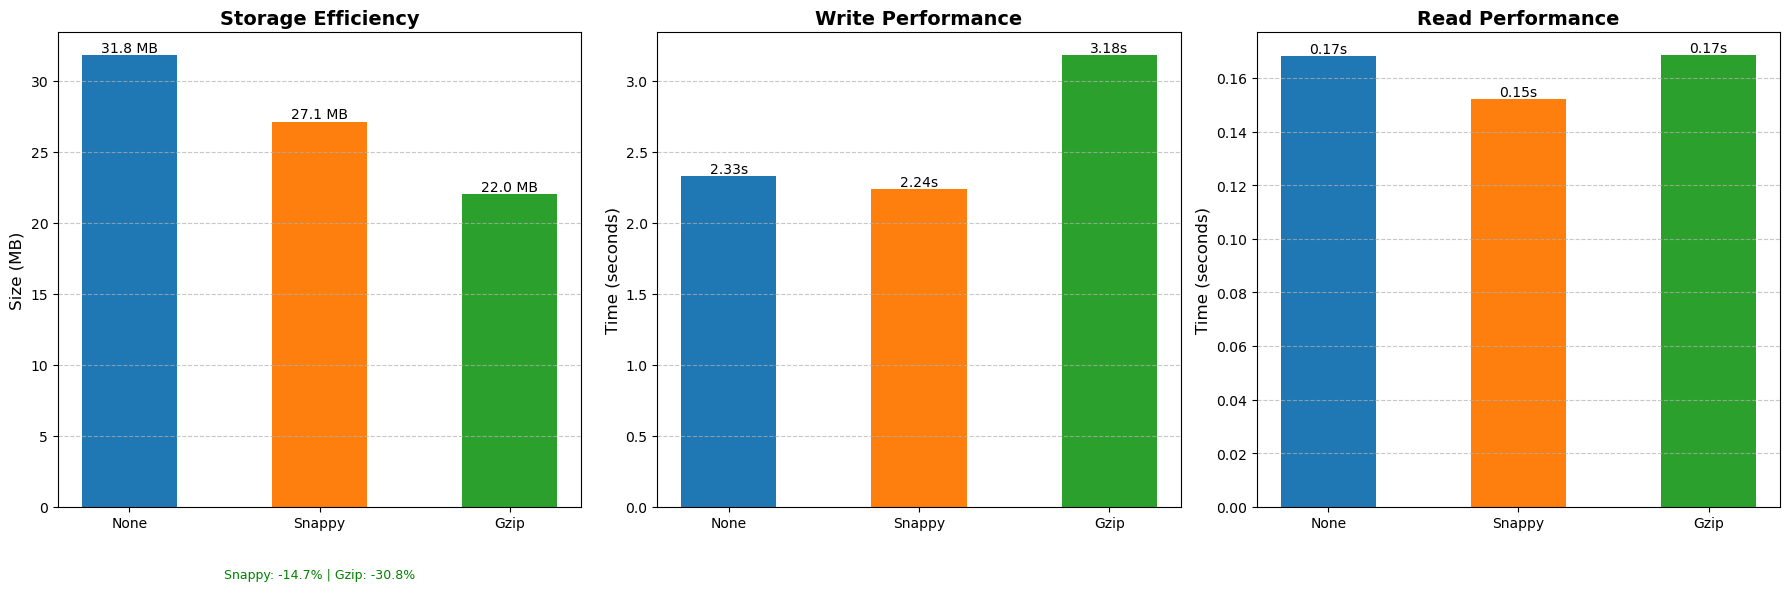


SUMMARY METRICS
Method     Size (MB)    Write (s)    Read (s)    
----------------------------------------------------------------------
None       31.80        2.331        0.168       
Snappy     27.12        2.237        0.152       
Gzip       22.00        3.183        0.169       

💡 Fastest Read: Snappy
💡 Smallest Size: Gzip
💡 Best Balance: Snappy (Usually)


In [16]:

# ============================================
# 1. EXECUTE COMPRESSION TESTS
# ============================================

none_path = '/tmp/network_none.parquet'
snappy_path = '/tmp/network_snappy.parquet' # Assuming this exists from previous step
gzip_path = '/tmp/network_gzip.parquet'     # Assuming this exists from previous step

# Helper to get size in MB
def get_size_mb(path):
    if not os.path.exists(path):
        return 0
    return sum(
        os.path.getsize(os.path.join(path, f)) 
        for f in os.listdir(path) 
        if f.endswith('.parquet')
    ) / (1024 * 1024)

# --- NONE Compression ---
if os.path.exists(none_path):
    shutil.rmtree(none_path)

start = time.time()
df_csv.write.mode('overwrite').option('compression', 'none').parquet(none_path)
none_write_time = time.time() - start
none_size = get_size_mb(none_path)

start = time.time()
df_none = spark.read.parquet(none_path)
none_count = df_none.count()
none_read_time = time.time() - start

# --- SNAPPY Compression (Re-calculate to ensure variables exist) ---
if os.path.exists(snappy_path):
    shutil.rmtree(snappy_path)

start = time.time()
df_csv.write.mode('overwrite').option('compression', 'snappy').parquet(snappy_path)
snappy_write_time = time.time() - start
snappy_size = get_size_mb(snappy_path)

start = time.time()
df_snappy = spark.read.parquet(snappy_path)
snappy_count = df_snappy.count()
snappy_read_time = time.time() - start

# --- GZIP Compression (Re-calculate to ensure variables exist) ---
if os.path.exists(gzip_path):
    shutil.rmtree(gzip_path)

start = time.time()
df_csv.write.mode('overwrite').option('compression', 'gzip').parquet(gzip_path)
gzip_write_time = time.time() - start
gzip_size = get_size_mb(gzip_path)

start = time.time()
df_gzip = spark.read.parquet(gzip_path)
gzip_count = df_gzip.count()
gzip_read_time = time.time() - start

# ============================================
# 2. PREPARE DATA FOR PLOTTING
# ============================================

methods = ['None', 'Snappy', 'Gzip']
sizes = [none_size, snappy_size, gzip_size]
write_times = [none_write_time, snappy_write_time, gzip_write_time]
read_times = [none_read_time, snappy_read_time, gzip_read_time]

# Colors for consistency
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

# ============================================
# 3. VISUALIZATION
# ============================================

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# --- Chart 1: File Size Comparison ---
bars1 = ax[0].bar(methods, sizes, color=colors, width=0.5)
ax[0].set_ylabel('Size (MB)', fontsize=12)
ax[0].set_title('Storage Efficiency', fontsize=14, fontweight='bold')
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Add labels
for bar, size in zip(bars1, sizes):
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width() / 2., height,
               f'{size:.1f} MB', ha='center', va='bottom', fontsize=10)

# Calculate savings relative to None
snappy_save = ((none_size - snappy_size) / none_size) * 100
gzip_save = ((none_size - gzip_size) / none_size) * 100
ax[0].text(0.5, -0.15, f'Snappy: -{snappy_save:.1f}% | Gzip: -{gzip_save:.1f}%', 
           ha='center', transform=ax[0].transAxes, fontsize=9, color='green')

# --- Chart 2: Write Time Comparison ---
bars2 = ax[1].bar(methods, write_times, color=colors, width=0.5)
ax[1].set_ylabel('Time (seconds)', fontsize=12)
ax[1].set_title('Write Performance', fontsize=14, fontweight='bold')
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

for bar, t in zip(bars2, write_times):
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width() / 2., height,
               f'{t:.2f}s', ha='center', va='bottom', fontsize=10)

# --- Chart 3: Read Time Comparison ---
bars3 = ax[2].bar(methods, read_times, color=colors, width=0.5)
ax[2].set_ylabel('Time (seconds)', fontsize=12)
ax[2].set_title('Read Performance', fontsize=14, fontweight='bold')
ax[2].grid(axis='y', linestyle='--', alpha=0.7)

for bar, t in zip(bars3, read_times):
    height = bar.get_height()
    ax[2].text(bar.get_x() + bar.get_width() / 2., height,
               f'{t:.2f}s', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================
# 4. CONCISE SUMMARY TABLE
# ============================================

print("\n" + "=" * 70)
print("SUMMARY METRICS")
print("=" * 70)
print(f"{'Method':<10} {'Size (MB)':<12} {'Write (s)':<12} {'Read (s)':<12}")
print("-" * 70)
print(f"{'None':<10} {none_size:<12.2f} {none_write_time:<12.3f} {none_read_time:<12.3f}")
print(f"{'Snappy':<10} {snappy_size:<12.2f} {snappy_write_time:<12.3f} {snappy_read_time:<12.3f}")
print(f"{'Gzip':<10} {gzip_size:<12.2f} {gzip_write_time:<12.3f} {gzip_read_time:<12.3f}")
print("=" * 70)

# Quick Recommendation Logic
best_read_method = methods[np.argmin(read_times)]
best_size_method = methods[np.argmin(sizes)]

print(f"\n💡 Fastest Read: {best_read_method}")
print(f"💡 Smallest Size: {best_size_method}")
print(f"💡 Best Balance: Snappy (Usually)")

Running Predicate Pushdown & Column Pruning Tests...
Filtering on:  Destination Port = '54865'


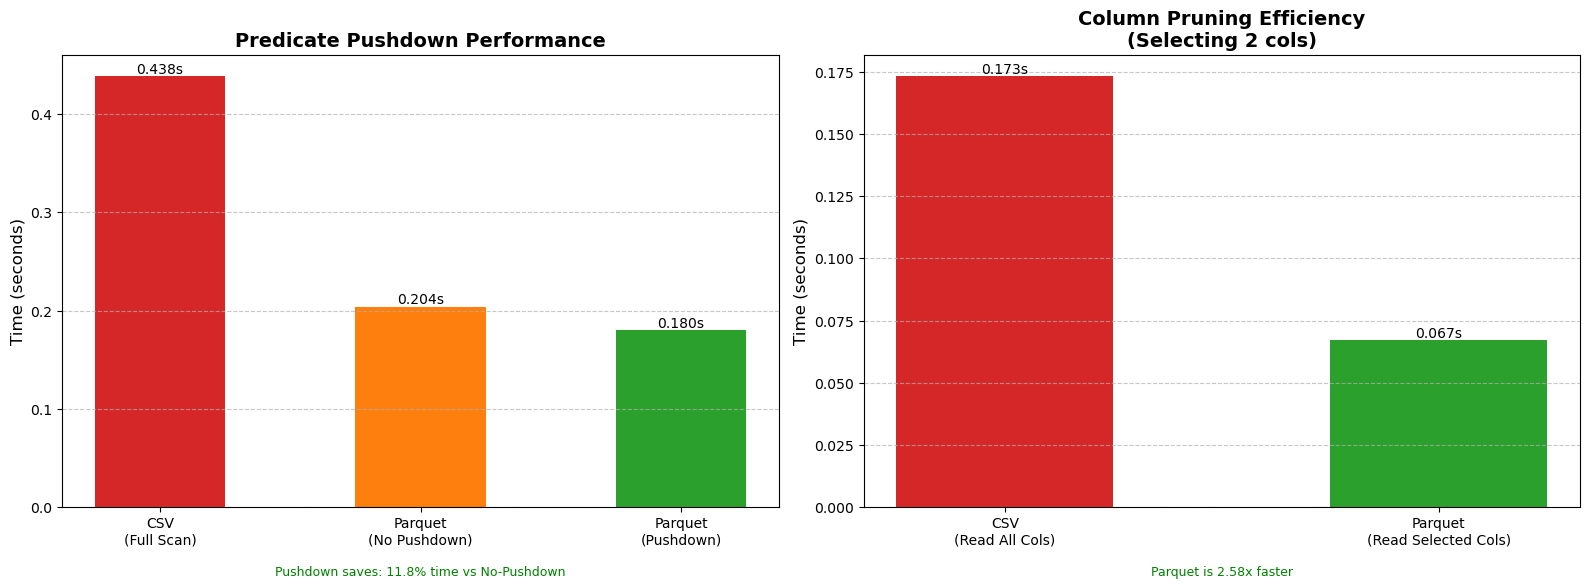


SUMMARY METRICS

1. PREDICATE PUSHDOWN (Filtering)
   CSV (Full Scan):       0.438s
   Parquet (No Pushdown): 0.204s
   Parquet (Pushdown):    0.180s  <-- Fastest

2. COLUMN PRUNING (Selection)
   CSV (Reads all cols):  0.173s
   Parquet (Pruned):      0.067s  <-- Efficient

💡 KEY INSIGHTS
• Parquet + Pushdown skips irrelevant data blocks entirely.
• Parquet + Pruning reads only the specific columns needed.
• CSV always requires full scans for both operations.


In [17]:

# ============================================
# 1. EXECUTE TESTS
# ============================================

print("Running Predicate Pushdown & Column Pruning Tests...")

# Pick a column and value for filtering
# Ensure df_csv is loaded from previous steps
filter_col = df_csv.columns[0] 
sample_val = df_csv.select(filter_col).distinct().first()[0]

print(f"Filtering on: {filter_col} = '{sample_val}'")

# --- 1. CSV (Full Scan) ---
start = time.time()
csv_result = df_csv.filter(df_csv[filter_col] == sample_val).count()
csv_filter_time = time.time() - start

# --- 2. Parquet (Pushdown DISABLED) ---
start = time.time()
df_pq_no_push = spark.read.option("parquet.filter.pushdown", "false").parquet(parquet_path)
pq_no_push_result = df_pq_no_push.filter(df_pq_no_push[filter_col] == sample_val).count()
pq_no_push_time = time.time() - start

# --- 3. Parquet (Pushdown ENABLED) ---
start = time.time()
df_pq_push = spark.read.option("parquet.filter.pushdown", "true").parquet(parquet_path)
pq_push_result = df_pq_push.filter(df_pq_push[filter_col] == sample_val).count()
pq_push_time = time.time() - start

# --- 4. Column Pruning Tests ---
selected_cols = df_csv.columns[:2] # Select first 2 columns

# CSV Pruning (Reads all, then selects)
start = time.time()
df_csv.select(*selected_cols).count()
csv_prune_time = time.time() - start

# Parquet Pruning (Reads only needed columns - Default behavior)
start = time.time()
df_pq.select(*selected_cols).count()
pq_prune_time = time.time() - start

# ============================================
# 2. VISUALIZATION
# ============================================

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Predicate Pushdown Comparison ---
methods_pushdown = ['CSV\n(Full Scan)', 'Parquet\n(No Pushdown)', 'Parquet\n(Pushdown)']
times_pushdown = [csv_filter_time, pq_no_push_time, pq_push_time]
colors_pushdown = ['#d62728', '#ff7f0e', '#2ca02c'] # Red, Orange, Green

bars1 = ax[0].bar(methods_pushdown, times_pushdown, color=colors_pushdown, width=0.5)
ax[0].set_ylabel('Time (seconds)', fontsize=12)
ax[0].set_title('Predicate Pushdown Performance', fontsize=14, fontweight='bold')
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Add labels
for bar, t in zip(bars1, times_pushdown):
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width() / 2., height,
               f'{t:.3f}s', ha='center', va='bottom', fontsize=10)

# Calculate improvement
pushdown_improvement = ((pq_no_push_time - pq_push_time) / pq_no_push_time) * 100 if pq_no_push_time > 0 else 0
ax[0].text(0.5, -0.15, f'Pushdown saves: {pushdown_improvement:.1f}% time vs No-Pushdown', 
           ha='center', transform=ax[0].transAxes, fontsize=9, color='green')

# --- Chart 2: Column Pruning Comparison ---
methods_prune = ['CSV\n(Read All Cols)', 'Parquet\n(Read Selected Cols)']
times_prune = [csv_prune_time, pq_prune_time]
colors_prune = ['#d62728', '#2ca02c'] # Red, Green

bars2 = ax[1].bar(methods_prune, times_prune, color=colors_prune, width=0.5)
ax[1].set_ylabel('Time (seconds)', fontsize=12)
ax[1].set_title(f'Column Pruning Efficiency\n(Selecting {len(selected_cols)} cols)', fontsize=14, fontweight='bold')
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

# Add labels
for bar, t in zip(bars2, times_prune):
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width() / 2., height,
               f'{t:.3f}s', ha='center', va='bottom', fontsize=10)

# Calculate speedup
prune_speedup = csv_prune_time / pq_prune_time if pq_prune_time > 0 else 0
ax[1].text(0.5, -0.15, f'Parquet is {prune_speedup:.2f}x faster', 
           ha='center', transform=ax[1].transAxes, fontsize=9, color='green')

plt.tight_layout()
plt.show()

# ============================================
# 3. CONCISE SUMMARY
# ============================================

print("\n" + "=" * 60)
print("SUMMARY METRICS")
print("=" * 60)

print("\n1. PREDICATE PUSHDOWN (Filtering)")
print(f"   CSV (Full Scan):       {csv_filter_time:.3f}s")
print(f"   Parquet (No Pushdown): {pq_no_push_time:.3f}s")
print(f"   Parquet (Pushdown):    {pq_push_time:.3f}s  <-- Fastest")

print("\n2. COLUMN PRUNING (Selection)")
print(f"   CSV (Reads all cols):  {csv_prune_time:.3f}s")
print(f"   Parquet (Pruned):      {pq_prune_time:.3f}s  <-- Efficient")

print("\n" + "=" * 60)
print("💡 KEY INSIGHTS")
print("=" * 60)
print("• Parquet + Pushdown skips irrelevant data blocks entirely.")
print("• Parquet + Pruning reads only the specific columns needed.")
print("• CSV always requires full scans for both operations.")

Running Single vs Multiple Parquet Files Test...


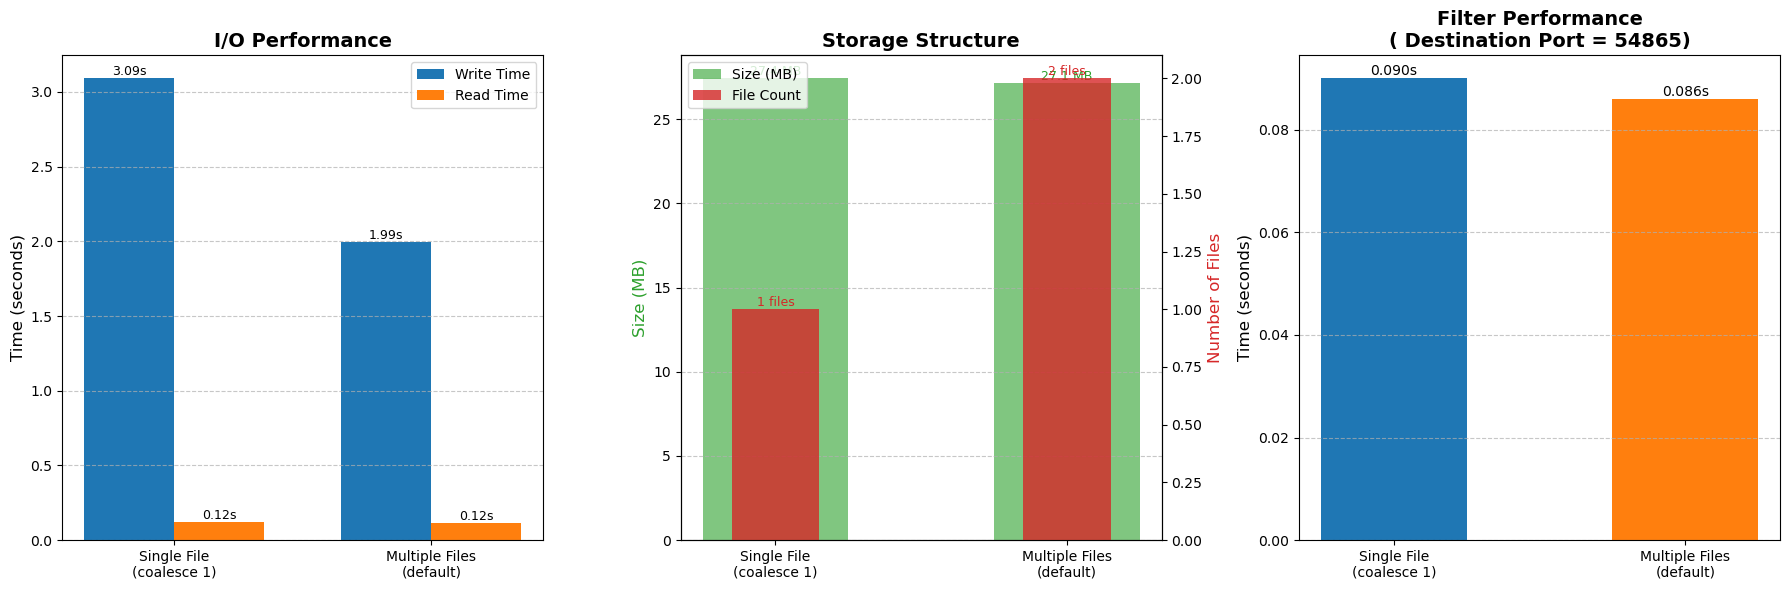


SUMMARY METRICS
Metric               Single File     Multiple Files 
------------------------------------------------------------
Write Time           3.091           1.995          
Read Time            0.123           0.116          
Filter Time          0.090           0.086          
File Count           1               2              
Total Size (MB)      27.42           27.12          

🏆 Winner for Large Data: Multiple Files (Better Parallelism)


In [18]:
import time
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# 1. EXECUTE TESTS
# ============================================

single_parquet_path = '/tmp/single_parquet_file.parquet'
multi_parquet_path = '/tmp/multi_parquet_files.parquet'

print("Running Single vs Multiple Parquet Files Test...")

# Helper to get size and count
def get_metrics(path):
    if not os.path.exists(path):
        return 0, 0, []
    files = [f for f in os.listdir(path) if f.endswith('.parquet')]
    total_size = sum(os.path.getsize(os.path.join(path, f)) for f in files) / (1024 * 1024)
    return total_size, len(files), files

# --- 1. Single File (Coalesce 1) ---
if os.path.exists(single_parquet_path):
    shutil.rmtree(single_parquet_path)

start = time.time()
df_csv.coalesce(1).write.mode('overwrite').parquet(single_parquet_path)
single_write_time = time.time() - start

single_size, single_file_count, _ = get_metrics(single_parquet_path)

start = time.time()
df_single = spark.read.parquet(single_parquet_path)
single_count = df_single.count()
single_read_time = time.time() - start

# --- 2. Multiple Files (Default Parallelism) ---
if os.path.exists(multi_parquet_path):
    shutil.rmtree(multi_parquet_path)

start = time.time()
df_csv.write.mode('overwrite').parquet(multi_parquet_path)
multi_write_time = time.time() - start

multi_size, multi_file_count, _ = get_metrics(multi_parquet_path)

start = time.time()
df_multi = spark.read.parquet(multi_parquet_path)
multi_count = df_multi.count()
multi_read_time = time.time() - start

# --- 3. Filter Performance ---
filter_col = df_csv.columns[0]
sample_val = df_csv.select(filter_col).distinct().first()[0]

start = time.time()
single_filtered = df_single.filter(df_single[filter_col] == sample_val).count()
single_filter_time = time.time() - start

start = time.time()
multi_filtered = df_multi.filter(df_multi[filter_col] == sample_val).count()
multi_filter_time = time.time() - start

# ============================================
# 2. VISUALIZATION
# ============================================

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

methods = ['Single File\n(coalesce 1)', 'Multiple Files\n(default)']
colors = ['#1f77b4', '#ff7f0e'] # Blue, Orange

# --- Chart 1: I/O Performance (Write & Read) ---
x = np.arange(len(methods))
width = 0.35

bars1 = ax[0].bar(x - width/2, [single_write_time, multi_write_time], width, label='Write Time', color='#1f77b4')
bars2 = ax[0].bar(x + width/2, [single_read_time, multi_read_time], width, label='Read Time', color='#ff7f0e')

ax[0].set_ylabel('Time (seconds)', fontsize=12)
ax[0].set_title('I/O Performance', fontsize=14, fontweight='bold')
ax[0].set_xticks(x)
ax[0].set_xticklabels(methods)
ax[0].legend()
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Add labels
for bar in bars1:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width() / 2., height, f'{height:.2f}s', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width() / 2., height, f'{height:.2f}s', ha='center', va='bottom', fontsize=9)

# --- Chart 2: File Management (Count & Size) ---
# Note: Size is usually similar, so we focus on File Count log scale or just count
# Since count can be huge, let's use a secondary axis or just show count clearly
ax2 = ax[1].twinx()

bars3 = ax[1].bar(methods, [single_size, multi_size], color='#2ca02c', width=0.5, label='Size (MB)', alpha=0.6)
bars4 = ax2.bar(methods, [single_file_count, multi_file_count], color='#d62728', width=0.3, label='File Count', alpha=0.8)

ax[1].set_ylabel('Size (MB)', color='#2ca02c', fontsize=12)
ax2.set_ylabel('Number of Files', color='#d62728', fontsize=12)
ax[1].set_title('Storage Structure', fontsize=14, fontweight='bold')
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

# Add labels for Size
for bar in bars3:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width() / 2., height, f'{height:.1f} MB', ha='center', va='bottom', fontsize=9, color='#2ca02c')

# Add labels for Count
for bar in bars4:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2., height, f'{int(height)} files', ha='center', va='bottom', fontsize=9, color='#d62728')

# Combine legends
lines1, labels1 = ax[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# --- Chart 3: Filter Performance ---
bars5 = ax[2].bar(methods, [single_filter_time, multi_filter_time], color=colors, width=0.5)
ax[2].set_ylabel('Time (seconds)', fontsize=12)
ax[2].set_title(f'Filter Performance\n({filter_col} = {sample_val})', fontsize=14, fontweight='bold')
ax[2].grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars5:
    height = bar.get_height()
    ax[2].text(bar.get_x() + bar.get_width() / 2., height, f'{height:.3f}s', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================
# 3. CONCISE SUMMARY
# ============================================

print("\n" + "=" * 60)
print("SUMMARY METRICS")
print("=" * 60)
print(f"{'Metric':<20} {'Single File':<15} {'Multiple Files':<15}")
print("-" * 60)
print(f"{'Write Time':<20} {single_write_time:<15.3f} {multi_write_time:<15.3f}")
print(f"{'Read Time':<20} {single_read_time:<15.3f} {multi_read_time:<15.3f}")
print(f"{'Filter Time':<20} {single_filter_time:<15.3f} {multi_filter_time:<15.3f}")
print(f"{'File Count':<20} {single_file_count:<15} {multi_file_count:<15}")
print(f"{'Total Size (MB)':<20} {single_size:<15.2f} {multi_size:<15.2f}")
print("=" * 60)

# Recommendation Logic
if multi_read_time < single_read_time:
    print("\n🏆 Winner for Large Data: Multiple Files (Better Parallelism)")
else:
    print("\n🏆 Winner for Small Data: Single File (Less Overhead)")

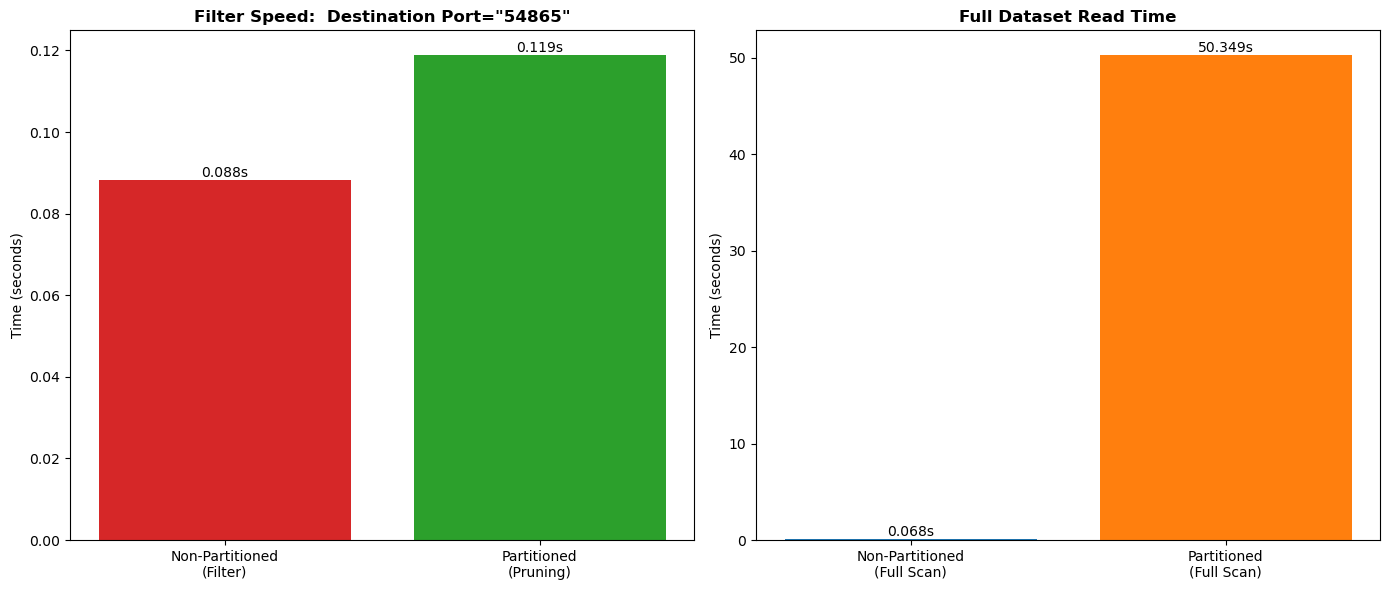

✅ Partitioning Write Time: 163.143s
🚀 Pruning Speedup: 0.74x faster than filtering non-partitioned data


In [19]:
import time, os, shutil, matplotlib.pyplot as plt

partitioned_path = '/tmp/partitioned_by_label.parquet'
partition_col = "Label" if "Label" in df_csv.columns else df_csv.columns[0]

# 1. Write Partitioned Data
if os.path.exists(partitioned_path): shutil.rmtree(partitioned_path)
start = time.time()
df_csv.write.mode('overwrite').partitionBy(partition_col).parquet(partitioned_path)
part_write_time = time.time() - start

# 2. Test Queries
sample_val = df_csv.select(partition_col).distinct().first()[0]

# Non-Partitioned Filter
start = time.time()
df_pq.filter(df_pq[partition_col] == sample_val).count()
np_filter_time = time.time() - start

# Partition Pruning (Direct Read)
part_path = f"{partitioned_path}/{partition_col}={sample_val}"
start = time.time()
spark.read.parquet(part_path).count()
pruning_time = time.time() - start

# Full Reads (Reference)
start = time.time(); df_pq.count(); full_np_read = time.time() - start
start = time.time(); spark.read.parquet(partitioned_path).count(); full_part_read = time.time() - start

# 3. Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Filter Performance
methods = ['Non-Partitioned\n(Filter)', 'Partitioned\n(Pruning)']
times = [np_filter_time, pruning_time]
bars = ax[0].bar(methods, times, color=['#d62728', '#2ca02c'])
ax[0].set_title(f'Filter Speed: {partition_col}="{sample_val}"', fontweight='bold')
ax[0].set_ylabel('Time (seconds)')
for b, t in zip(bars, times): ax[0].text(b.get_x() + b.get_width()/2, t, f'{t:.3f}s', ha='center', va='bottom')

# Chart 2: Full Read Comparison
methods_full = ['Non-Partitioned\n(Full Scan)', 'Partitioned\n(Full Scan)']
times_full = [full_np_read, full_part_read]
bars_full = ax[1].bar(methods_full, times_full, color=['#1f77b4', '#ff7f0e'])
ax[1].set_title('Full Dataset Read Time', fontweight='bold')
ax[1].set_ylabel('Time (seconds)')
for b, t in zip(bars_full, times_full): ax[1].text(b.get_x() + b.get_width()/2, t, f'{t:.3f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"✅ Partitioning Write Time: {part_write_time:.3f}s")
print(f"🚀 Pruning Speedup: {np_filter_time/pruning_time:.2f}x faster than filtering non-partitioned data")